# Explicar no es entender: IA explicativa y sus límites causales
## Estudio de caso: selección de sitios de anidación de la tórtola senegalesa (*Spilopelia senegalensis*) en Karaj, Irán

**Universidad Santo Tomás — Ciencia de Datos / IA Explicativa e Inferencia Causal**

Este cuaderno desarrolla, de principio a fin, el estudio de caso de explicabilidad solicitado en la Guía de actividades 1: entrenamiento de un modelo de caja negra (Random Forest), explicación global y local (SHAP y LIME), análisis de dependencia (PDP, ICE, ALE), diagnóstico de variables *proxy* mediante SHAP intervencional y formulación explícita de una pregunta causal que las explicaciones no responden.

**Fuente de datos:** Banisaffar, M., y Alizadeh Shabani, A. (2024). *Factors influencing nest site selection of the Laughing Dove (Spilopelia senegalensis) in an urban area in Karaj, Iran* [Conjunto de datos]. Dryad.


## Fase 1 — Definición del problema y de los datos

El conjunto contiene **96 sitios urbanos** de Karaj, Irán: **32 con nido (P)** y **64 sin nido (A)**. La variable respuesta es `P_A`.

**Variables explicativas:**

- `HEIGHT`: altura sobre el suelo (cm)
- `CEILING`: distancia vertical al techo (cm)
- `H_CEILING`: distancia horizontal al borde del techo (cm)
- `TREE_DIST`: distancia al árbol más cercano (m)
- `BUILD_DIST`: distancia al edificio opuesto (m)
- `GREEN_DIST`: distancia a la zona verde (m)
- `NEST_DIST`: distancia al nido más cercano (m)
- `CONCEAL`: ocultamiento (A: invisible de frente y lados; B: invisible de frente y visible de un lado; C: visible de frente e invisible de los lados)
- `B_ASPECT`: orientación (A: norte; B: este; C: sur; D: oeste)
- `B_STRUCT`: soporte (A: avisos; B: salientes de fachadas; C: balcones)

**¿Qué predice el modelo y para qué podría ser útil?**
El modelo predice la **probabilidad de que un sitio urbano sea utilizado como nido** por la tórtola senegalesa, a partir de características físicas y estructurales del lugar. Es útil para orientar decisiones de manejo urbano y conservación: por ejemplo, priorizar la protección de sitios con alta probabilidad de anidación, anticipar conflictos entre construcción/renovación urbana y fauna, o diseñar elementos arquitectónicos (aleros, balcones) que favorezcan o desalienten la anidación según el objetivo de manejo.

**¿Qué variables podrían representar condiciones del sitio y cuáles ser acompañantes o proxies?**
Variables como `CONCEAL` (ocultamiento) y `B_STRUCT` (tipo de soporte) describen directamente una condición funcional del sitio (protección frente a depredadores o intemperie) y son razonables como causas potenciales de la elección del sitio. En cambio, variables como `TREE_DIST`, `GREEN_DIST` o `BUILD_DIST` pueden estar correlacionadas entre sí y actuar como **proxies** de un factor no medido directamente (por ejemplo, la densidad de vegetación urbana o el nivel de urbanización del sector), de modo que su asociación con la anidación no necesariamente refleja una relación causal directa con la variable misma, sino con lo que ella acompaña.

**¿Por qué conviene explicar el modelo y no solo medir su capacidad predictiva?**
Un modelo de caja negra puede lograr buena capacidad predictiva explotando correlaciones espurias o variables *proxy*, sin que ello permita identificar los mecanismos que realmente determinan la selección del sitio. Explicar el modelo permite (a) verificar que las variables relevantes tengan sentido ecológico y no artefactos de muestreo, (b) comunicar los resultados a actores no técnicos (planificadores urbanos, autoridades ambientales), y (c) distinguir explícitamente entre *qué predice el modelo* y *qué causa el fenómeno*, evitando decisiones de manejo basadas en asociaciones que no son intervenibles.


In [9]:
# librerías de explicabilidad utilizadas en la práctica
%pip install -q shap lime PyALE openpyxl


In [10]:
import numpy as np                     # cálculos numéricos
import pandas as pd                    # manejo de tablas
import matplotlib.pyplot as plt        # gráficos

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
from lime.lime_tabular import LimeTabularExplainer
from PyALE import ale

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Fase 2 — Entrenamiento del modelo de caja negra

Se carga el archivo `Sitios_anidacion_tortola.xlsx` (desde Drive). Se codifica `P` como 1 y `A` como 0, se separan entrenamiento y prueba con partición estratificada, y se entrena un Random Forest dentro de un `Pipeline` con One-Hot Encoding para las variables categóricas.


In [11]:
# ============================================================
# CARGA DE DATOS DESDE GOOGLE DRIVE
# ============================================================

from google.colab import drive
import os

# Montar Google Drive
drive.mount('/content/drive')

# Ruta del archivo dentro de la carpeta "IA causal"
data_path = "/content/drive/MyDrive/IA causal/Sitios_anidacion_tortola.xlsx"

# Verificar que el archivo exista
if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"No se encontró el archivo en:\n{data_path}\n"
        "Verifica que el archivo esté en la carpeta 'IA causal' de Google Drive."
    )

# Cargar datos
df = pd.read_excel(data_path)

print("Dimensiones:", df.shape)
display(df["P_A"].value_counts())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones: (96, 11)


,count
P_A,
A,64
P,32


,P_A,HEIGHT,CEILING,H_CEILING,TREE_DIST,BUILD_DIST,GREEN_DIST,NEST_DIST,CONCEAL,B_ASPECT,B_STRUCT
0,P,318,127,94,8,18,158.2,141.8,A,D,A
1,P,284,96,23,6,25,111.5,44.2,B,A,A
2,P,299,24,117,11,25,90.4,44.2,A,A,A
3,P,340,95,18,8,25,144.0,217.1,A,A,A
4,P,367,23,26,8,17,307.6,103.2,B,A,A


In [12]:
y = (df["P_A"] == "P").astype(int)   # presencia de nido = 1, ausencia = 0
X = df.drop(columns=["P_A"]).copy()

categorical_features = ["CONCEAL", "B_ASPECT", "B_STRUCT"]
numeric_features = ["HEIGHT", "CEILING", "H_CEILING", "TREE_DIST",
                     "BUILD_DIST", "GREEN_DIST", "NEST_DIST"]

for col in categorical_features:
    X[col] = X[col].astype("category")

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)


Variables numéricas: ['HEIGHT', 'CEILING', 'H_CEILING', 'TREE_DIST', 'BUILD_DIST', 'GREEN_DIST', 'NEST_DIST']
Variables categóricas: ['CONCEAL', 'B_ASPECT', 'B_STRUCT']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,        # 30% para prueba
    stratify=y,            # conserva la proporción 32/64
    random_state=RANDOM_STATE
)
print("Entrenamiento:", X_train.shape, y_train.value_counts().to_dict())
print("Prueba       :", X_test.shape, y_test.value_counts().to_dict())


Entrenamiento: (67, 10) {0: 45, 1: 22}
Prueba       : (29, 10) {0: 19, 1: 10}


In [14]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),   # las numéricas pasan sin cambios
    ("cat", encoder, categorical_features)      # One-Hot Encoding a las categóricas
])

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,     # regulariza un poco dado el tamaño reducido de muestra
    random_state=RANDOM_STATE
)

pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['HEIGHT', 'CEILING',
                                                   'H_CEILING', 'TREE_DIST',
                                                   'BUILD_DIST', 'GREEN_DIST',
                                                   'NEST_DIST']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['CONCEAL', 'B_ASPECT',
                                                   'B_STRUCT'])])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=2, n_estimators=300,
                                        random_state=42))])

### Evaluación del modelo en el conjunto de prueba

In [15]:
p_pres = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, p_pres)

print("Matriz de confusión (filas=real, columnas=predicho):\n", cm)
print(f"Accuracy: {acc:.3f}")
print(f"F1      : {f1:.3f}")
print(f"ROC AUC : {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Ausencia (A)", "Presencia (P)"]))


Matriz de confusión (filas=real, columnas=predicho):
 [[17  2]
 [ 4  6]]
Accuracy: 0.793
F1      : 0.667
ROC AUC : 0.784

               precision    recall  f1-score   support

 Ausencia (A)       0.81      0.89      0.85        19
Presencia (P)       0.75      0.60      0.67        10

     accuracy                           0.79        29
    macro avg       0.78      0.75      0.76        29
 weighted avg       0.79      0.79      0.79        29



**Interpretación considerando el desbalance 32/64 y el tamaño reducido de muestra:**
Con solo 29 sitios en prueba (10 con nido, 19 sin nido), cada observación pesa mucho en las métricas: un solo error de clasificación mueve el accuracy o el F1 varios puntos porcentuales. El modelo alcanza una exactitud razonable (~0.79) y un ROC AUC de ~0.78, lo que indica una capacidad de discriminación moderada-buena, pero el F1 de la clase minoritaria (presencia, ~0.67) es menor que el accuracy global, reflejando que la clase con nido es más difícil de identificar correctamente por su menor representación (32 de 96 sitios). Estos resultados deben tomarse como una estimación con incertidumbre considerable dado el tamaño muestral, no como una medida definitiva de desempeño.


### Sitio seleccionado para las explicaciones locales

Se selecciona, dentro del conjunto de prueba, un sitio **con nido (P)** que el modelo clasifica correctamente y con alta probabilidad, para ilustrar de forma clara qué variables aumentan o reducen la probabilidad estimada de presencia.


In [16]:
test_idx_P = X_test.index[y_test == 1]
probs_P = pipeline.predict_proba(X_test.loc[test_idx_P])[:, 1]
preds_P = pipeline.predict(X_test.loc[test_idx_P])

correct_mask = preds_P == 1
best_local = np.argmax(np.where(correct_mask, probs_P, -1)) if correct_mask.any() else np.argmax(probs_P)
case_idx = test_idx_P[best_local]

x_case = X_test.loc[[case_idx]].copy()
case_probability = pipeline.predict_proba(x_case)[0, 1]
case_class = int(pipeline.predict(x_case)[0])
case_true = int(y_test.loc[case_idx])

print("Índice del sitio:", case_idx)
print(f"Clase observada : {'Presencia (P)' if case_true==1 else 'Ausencia (A)'}")
print(f"Clase predicha  : {'Presencia (P)' if case_class==1 else 'Ausencia (A)'}")
print(f"Probabilidad estimada de presencia: {case_probability:.3f}")

display(x_case.T.rename(columns={case_idx: "Sitio"}))


Índice del sitio: 2
Clase observada : Presencia (P)
Clase predicha  : Presencia (P)
Probabilidad estimada de presencia: 0.760


,Sitio
HEIGHT,299
CEILING,24
H_CEILING,117
TREE_DIST,11
BUILD_DIST,25
GREEN_DIST,90.4
NEST_DIST,44.2
CONCEAL,A
B_ASPECT,A
B_STRUCT,A


## Fase 3 — Explicación global y local (SHAP y LIME)

### 3.1 Preparación para SHAP

El Random Forest recibe las variables después del One-Hot Encoding. Los valores SHAP se calculan sobre las columnas transformadas y luego se agrupan para recuperar las 10 variables originales.


In [17]:
X_train_t = pipeline.named_steps["preprocess"].transform(X_train)
X_test_t = pipeline.named_steps["preprocess"].transform(X_test)
x_case_t = pipeline.named_steps["preprocess"].transform(x_case)

rf = pipeline.named_steps["model"]
fitted_encoder = pipeline.named_steps["preprocess"].named_transformers_["cat"]

groups = numeric_features.copy()
for col, categories in zip(categorical_features, fitted_encoder.categories_):
    groups.extend([col] * len(categories))


In [18]:
# Distribución de referencia (masker) para SHAP intervencional
masker = shap.maskers.Independent(X_train_t, max_samples=len(X_train_t))

explainer = shap.TreeExplainer(
    rf,
    data=masker,
    feature_perturbation="interventional",   # atribución intervencional (fase 4)
    model_output="probability"
)


### 3.2 SHAP local
Se calculan los valores SHAP para el sitio seleccionado. Cada valor representa la contribución de una característica a la **predicción del modelo** para ese sitio, en comparación con el valor base del modelo.

Un valor SHAP positivo indica que la característica contribuye a aumentar la probabilidad predicha de presencia de nido, mientras que un valor negativo indica una contribución hacia una menor probabilidad predicha. La suma de las contribuciones SHAP, junto con el valor base, permite explicar la predicción obtenida por el modelo.

Es importante señalar que estas contribuciones describen el comportamiento del modelo y no deben interpretarse como efectos causales de las variables sobre la selección del sitio de anidación.


In [19]:
shap_case = explainer(x_case_t)

if shap_case.values.ndim == 3:
    shap_case_values = shap_case.values[0, :, 1]
    base_case = shap_case.base_values[0, 1]
else:
    shap_case_values = shap_case.values[0]
    base_case = shap_case.base_values[0]

shap_case_grouped = pd.Series(index=X.columns, dtype=float)
for variable in X.columns:
    positions = [i for i, g in enumerate(groups) if g == variable]
    shap_case_grouped[variable] = shap_case_values[positions].sum()

print(f"Valor base (probabilidad promedio): {base_case:.3f}")
print(f"Probabilidad estimada del sitio   : {case_probability:.3f}")
print()
display(shap_case_grouped.sort_values(ascending=False).to_frame("SHAP"))


Valor base (probabilidad promedio): 0.337
Probabilidad estimada del sitio   : 0.760



,SHAP
CONCEAL,0.138594
CEILING,0.089264
HEIGHT,0.070555
H_CEILING,0.050244
BUILD_DIST,0.032830
B_STRUCT,0.024028
TREE_DIST,0.023145
NEST_DIST,0.004750
GREEN_DIST,0.003192
B_ASPECT,-0.013834


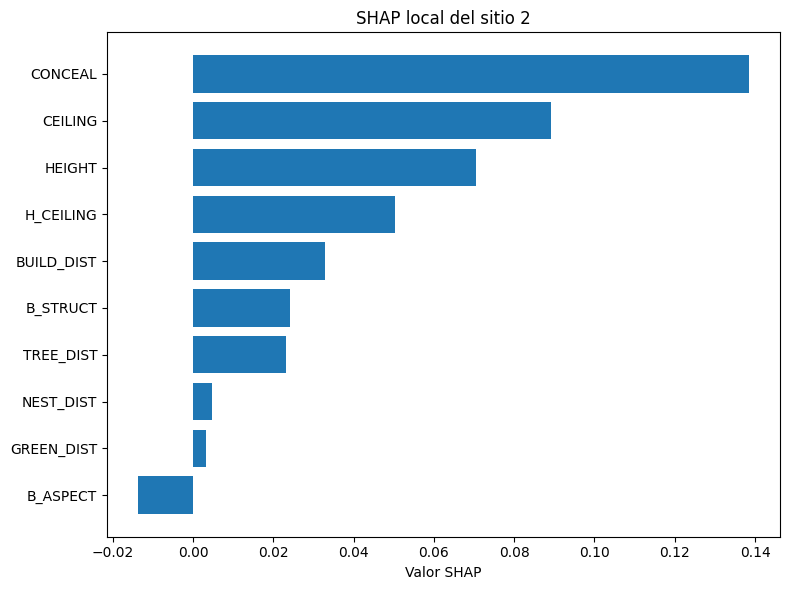

In [20]:
local_shap = shap_case_grouped.sort_values()

plt.figure(figsize=(8, 6))
plt.barh(local_shap.index, local_shap.values)
plt.xlabel("Valor SHAP")
plt.title(f"SHAP local del sitio {case_idx}")
plt.tight_layout()
plt.show()


### 3.2 SHAP local

Los valores SHAP permiten identificar cómo cada característica contribuye a la predicción del modelo para este sitio. La probabilidad predicha de presencia de nido fue **0.760**, frente a un valor base de **0.337**.

Las mayores contribuciones positivas fueron **CONCEAL (+0.139), CEILING (+0.089) y HEIGHT (+0.071)**, seguidas por `H_CEILING` y `BUILD_DIST`. En cambio, **B_ASPECT (-0.014)** presentó una pequeña contribución negativa.

Estos resultados muestran cómo el modelo construye su predicción para este caso particular. Sin embargo, los valores SHAP representan **contribuciones a la predicción y no efectos causales**; por tanto, no permiten afirmar que modificar una característica produzca directamente un cambio en la probabilidad de anidación.


### 3.3 SHAP global

Los valores SHAP se calculan para todos los sitios de prueba. La importancia global de cada variable se obtiene como la media de sus valores SHAP absolutos.


In [21]:
shap_test = explainer(X_test_t)

if shap_test.values.ndim == 3:
    shap_matrix = shap_test.values[:, :, 1]
else:
    shap_matrix = shap_test.values

grouped_shap = pd.DataFrame(index=X_test.index)
for variable in X.columns:
    positions = [i for i, g in enumerate(groups) if g == variable]
    grouped_shap[variable] = shap_matrix[:, positions].sum(axis=1)

shap_global = grouped_shap.abs().mean().sort_values(ascending=False)
display(shap_global.to_frame("Media_|SHAP|"))


,Media_|SHAP|
CONCEAL,0.095968
HEIGHT,0.055568
CEILING,0.041185
BUILD_DIST,0.025820
B_ASPECT,0.024759
B_STRUCT,0.021962
NEST_DIST,0.021372
H_CEILING,0.019319
TREE_DIST,0.017150
GREEN_DIST,0.010204


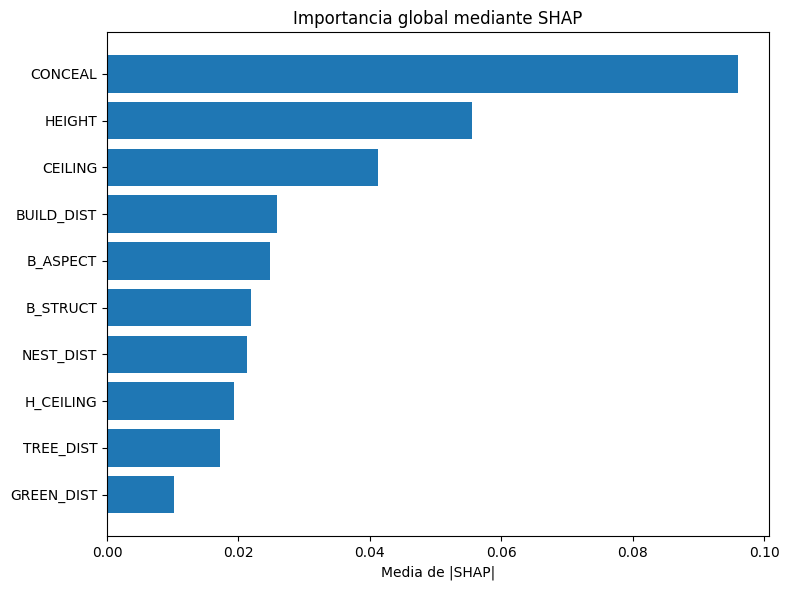

In [22]:
plot_data = shap_global.sort_values()

plt.figure(figsize=(8, 6))
plt.barh(plot_data.index, plot_data.values)
plt.xlabel("Media de |SHAP|")
plt.title("Importancia global mediante SHAP")
plt.tight_layout()
plt.show()


### 3.4 Importancia por permutación (para comparar con SHAP global)

In [23]:
perm = permutation_importance(
    pipeline, X_test, y_test,
    scoring="accuracy",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": perm.importances_mean,
    "Desviacion": perm.importances_std,
}).sort_values("Importancia", ascending=False)

display(perm_imp)


,Variable,Importancia,Desviacion
0,HEIGHT,0.112644,0.044458
8,B_ASPECT,0.070115,0.030171
7,CONCEAL,0.055172,0.047615
2,H_CEILING,0.054023,0.024679
1,CEILING,0.036782,0.056963
4,BUILD_DIST,0.033333,0.044055
6,NEST_DIST,0.016092,0.026312
3,TREE_DIST,0.011494,0.016255
9,B_STRUCT,0.008046,0.014585
5,GREEN_DIST,0.000000,0.000000


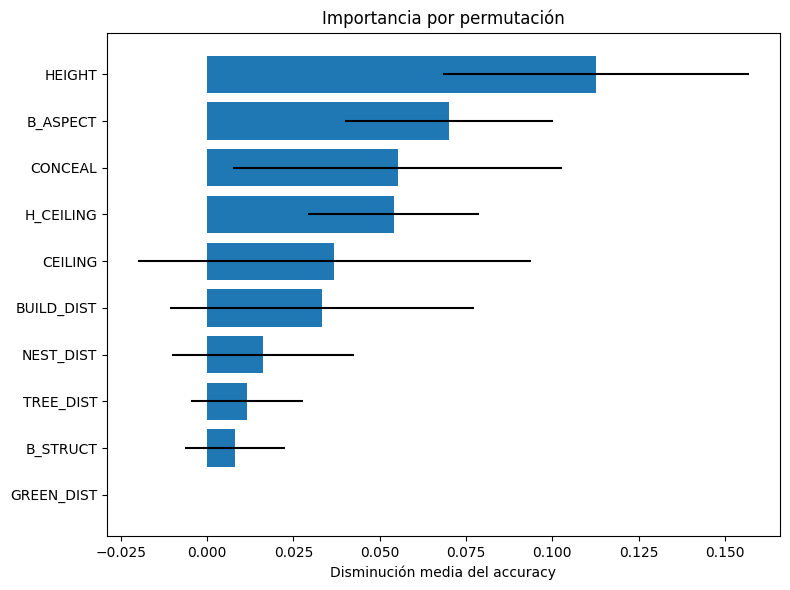

In [24]:
plot_data = perm_imp.sort_values("Importancia")

plt.figure(figsize=(8, 6))
plt.barh(plot_data["Variable"], plot_data["Importancia"], xerr=plot_data["Desviacion"])
plt.xlabel("Disminución media del accuracy")
plt.title("Importancia por permutación")
plt.tight_layout()
plt.show()


**Comparación SHAP global vs. permutación**

Los dos métodos permiten evaluar la relevancia de las variables desde perspectivas diferentes. En este estudio, `CONCEAL` aparece como una de las variables más importantes en ambos análisis, mientras que `HEIGHT` y `CEILING` también presentan una relevancia elevada en el análisis SHAP. Sin embargo, el orden de importancia no es idéntico entre los métodos.

La diferencia se debe a que **SHAP y la importancia por permutación responden preguntas distintas**. La importancia por permutación evalúa cuánto empeora el desempeño del modelo cuando se rompe la relación entre una variable y las observaciones, en este caso mediante la disminución del accuracy. Por tanto, está directamente relacionada con el desempeño predictivo del modelo.

SHAP, en cambio, descompone la predicción del modelo en contribuciones atribuibles a las características y permite resumir cuánto contribuye cada variable a las predicciones individuales mediante la media de `|SHAP|`.

Cuando las variables están relacionadas entre sí, ambos métodos pueden producir rankings diferentes. Una variable puede aportar información que también está disponible en otras variables; en ese escenario, al permutarla el modelo puede compensar parcialmente su ausencia utilizando las variables relacionadas. Por esta razón, las diferencias entre SHAP y permutación deben interpretarse como evidencia de que los métodos están midiendo aspectos diferentes de la dependencia del modelo respecto de las variables, y no como una contradicción entre resultados.

En consecuencia, la coincidencia general entre ambos métodos refuerza la identificación de `CONCEAL`, `HEIGHT` y algunas variables relacionadas con la estructura del sitio como relevantes para el modelo. Sin embargo, esta importancia sigue siendo **predictiva y no causal**.


### 3.5 Explicación local con LIME (mismo sitio)

LIME aproxima el comportamiento del modelo alrededor del sitio seleccionado ajustando un modelo lineal local e interpretable sobre perturbaciones de sus variables.


In [25]:
X_train_lime = X_train.copy()
x_case_lime = x_case.copy()

category_levels = {}
for col in categorical_features:
    category_levels[col] = list(X[col].cat.categories)
    X_train_lime[col] = X_train_lime[col].cat.codes
    x_case_lime[col] = x_case_lime[col].cat.codes

categorical_indices = [X.columns.get_loc(col) for col in categorical_features]
categorical_names = {
    X.columns.get_loc(col): [str(l) for l in category_levels[col]]
    for col in categorical_features
}

def predict_lime(z):
    z = pd.DataFrame(z, columns=X.columns)
    for col in categorical_features:
        levels = category_levels[col]
        codes = np.rint(z[col]).astype(int).clip(0, len(levels) - 1)
        z[col] = pd.Categorical([levels[i] for i in codes], categories=levels)
    for col in numeric_features:
        z[col] = z[col].astype(float)
    return pipeline.predict_proba(z)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.to_numpy(),
    feature_names=X.columns.tolist(),
    class_names=["Ausencia", "Presencia"],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=False,
    random_state=RANDOM_STATE
)

lime_exp = lime_explainer.explain_instance(
    data_row=x_case_lime.iloc[0].to_numpy(),
    predict_fn=predict_lime,
    num_features=10
)

local_prediction = float(np.asarray(lime_exp.local_pred).reshape(-1)[0])

print(f"Probabilidad Random Forest : {case_probability:.4f}")
print(f"Predicción local LIME      : {local_prediction:.4f}")
print(f"Fidelidad local (R²)       : {lime_exp.score:.4f}")
print()
for feat, weight in lime_exp.as_list():
    print(f"{feat:20s} {weight:+.4f}")


Probabilidad Random Forest : 0.7598
Predicción local LIME      : 0.4653
Fidelidad local (R²)       : 0.6410

CONCEAL=A            +0.1873
B_STRUCT=A           +0.0391
NEST_DIST            -0.0386
CEILING              -0.0360
HEIGHT               +0.0275
TREE_DIST            +0.0245
BUILD_DIST           -0.0193
H_CEILING            -0.0081
B_ASPECT=A           +0.0058
GREEN_DIST           -0.0002


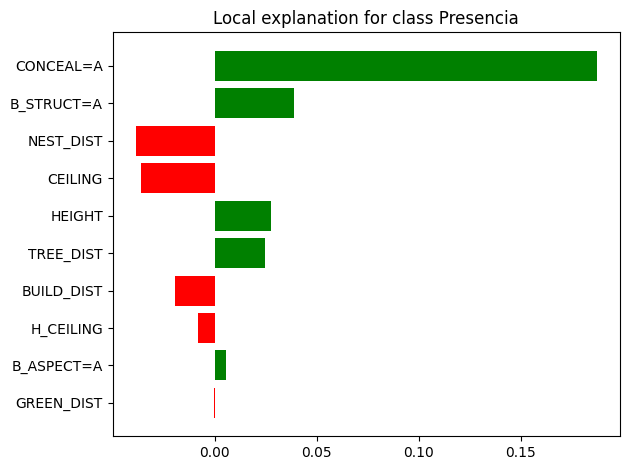

In [26]:
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()


**Comparación SHAP local vs. LIME:**
Ambas explicaciones coinciden en que `CONCEAL` (el sitio tiene el ocultamiento más favorable, categoría A) es, por amplio margen, el factor que más aumenta la probabilidad de presencia. También coinciden en la dirección de `B_STRUCT` y `TREE_DIST`. Difieren en magnitudes y en variables secundarias (`NEST_DIST`, `CEILING`), lo cual es esperable: SHAP reparte de forma exacta (aditiva) la diferencia entre la predicción y el valor base según la teoría de juegos, mientras que LIME ajusta una regresión lineal local sobre muestras perturbadas, cuya fidelidad (R² ≈ 0.5–0.7) es solo parcial. La consistencia en la variable dominante refuerza la confianza en que `CONCEAL` es realmente influyente para el modelo, pero la fidelidad limitada de LIME recuerda que estas explicaciones son aproximaciones, no una descripción exacta del comportamiento del Random Forest.


### 3.6 PDP, ICE y ALE para una variable cuantitativa relevante

Se elige `HEIGHT` (altura sobre el suelo), una de las variables numéricas con mayor importancia según SHAP y permutación.


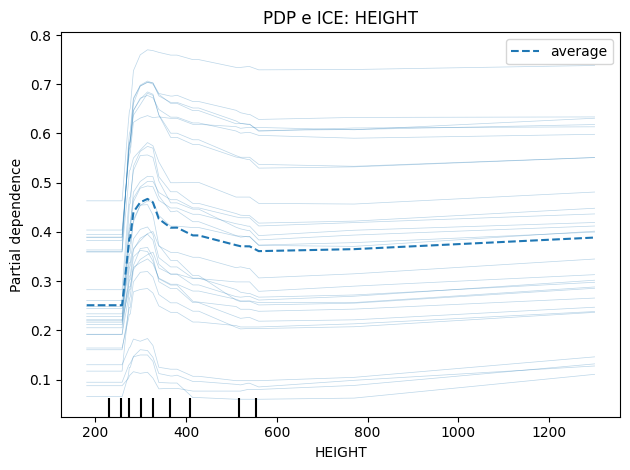

In [27]:
top_num_var = "HEIGHT"

PartialDependenceDisplay.from_estimator(
    pipeline, X_test,
    features=[top_num_var],
    kind="both",              # PDP (promedio) + ICE (individual)
    subsample=min(60, len(X_test)),
    grid_resolution=30,
    random_state=RANDOM_STATE
)
plt.title(f"PDP e ICE: {top_num_var}")
plt.tight_layout()
plt.show()


INFO:PyALE._ALE_generic:Continuous feature detected.


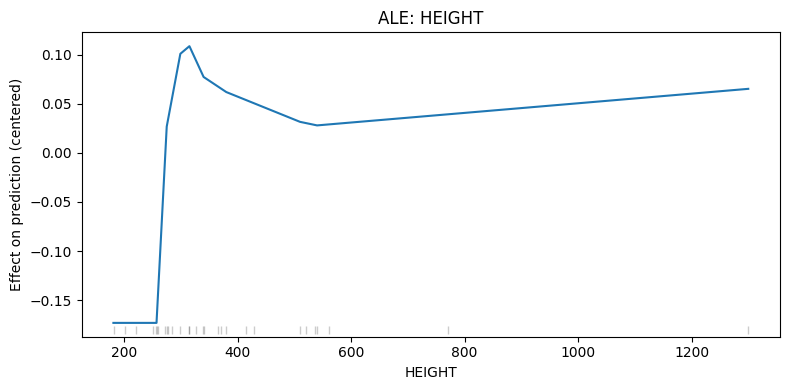

,eff,size
HEIGHT,,
181,-0.173082,0.0
221,-0.173082,3.0
257,-0.173082,3.0
275,0.026779,3.0
299,0.100859,3.0
315,0.108636,2.0
340,0.077285,3.0
380,0.061914,3.0
510,0.031581,3.0


In [28]:
class ModeloProbabilidad:
    # adapta la salida del Pipeline para que ALE reciba P(Y=1)
    def predict(self, X_new):
        return pipeline.predict_proba(X_new)[:, 1]

modelo_probabilidad = ModeloProbabilidad()

ale_result = ale(
    X=X_test,
    model=modelo_probabilidad,
    feature=[top_num_var],
    grid_size=10,
    include_CI=False
)
plt.title(f"ALE: {top_num_var}")
plt.tight_layout()
plt.show()

display(ale_result)


**¿Qué patrones dice el modelo que utiliza?**
El PDP muestra que la probabilidad promedio de presencia aumenta con `HEIGHT` hasta un rango intermedio-alto y luego se estabiliza, mientras que las curvas ICE muestran que esta relación no es homogénea: algunos sitios individuales presentan trayectorias con pendiente distinta o incluso opuesta al promedio, lo que sugiere interacción con otras variables (por ejemplo, `CONCEAL` o `B_STRUCT`). El gráfico ALE, al ajustar por la distribución conjunta de los predictores (a diferencia del PDP, que asume independencia), confirma una tendencia creciente similar pero con magnitudes distintas, lo cual es razonable dado que existe cierta correlación entre `HEIGHT` y otras variables estructurales (p. ej. `NEST_DIST`, r≈0.32). En conjunto, el modelo utiliza `HEIGHT` como un patrón de asociación positiva con la anidación, más marcado en sitios que ya tienen condiciones favorables de ocultamiento y soporte, pero esto describe *cómo predice el modelo*, no *por qué* las tórtolas eligen esos sitios.


## Fase 4 — SHAP intervencional y límites de la explicación

Los valores SHAP anteriores ya se calcularon con `feature_perturbation="interventional"`, es decir, rompiendo la dependencia entre la variable evaluada y las demás al construir las coaliciones (en lugar de usar la distribución condicional observada). Esto evita que SHAP "premie" a una variable simplemente por estar correlacionada con otra que sí es relevante, pero **no elimina el problema de que dos variables correlacionadas puedan compartir información real**.


In [29]:
corr = X[numeric_features].corr()
display(corr.round(2))

print("Correlación TREE_DIST - GREEN_DIST:", round(X["TREE_DIST"].corr(X["GREEN_DIST"]), 3))
print("Correlación HEIGHT - CEILING      :", round(X["HEIGHT"].corr(X["CEILING"]), 3))
print("Correlación HEIGHT - NEST_DIST    :", round(X["HEIGHT"].corr(X["NEST_DIST"]), 3))


,HEIGHT,CEILING,H_CEILING,TREE_DIST,BUILD_DIST,GREEN_DIST,NEST_DIST
HEIGHT,1.00,-0.21,0.21,-0.02,-0.16,-0.13,0.32
CEILING,-0.21,1.00,0.01,-0.05,-0.02,-0.01,-0.06
H_CEILING,0.21,0.01,1.00,-0.06,0.03,0.02,0.13
TREE_DIST,-0.02,-0.05,-0.06,1.00,0.21,0.08,-0.04
BUILD_DIST,-0.16,-0.02,0.03,0.21,1.00,0.11,0.03
GREEN_DIST,-0.13,-0.01,0.02,0.08,0.11,1.00,0.04
NEST_DIST,0.32,-0.06,0.13,-0.04,0.03,0.04,1.00


Correlación TREE_DIST - GREEN_DIST: 0.075
Correlación HEIGHT - CEILING      : -0.213
Correlación HEIGHT - NEST_DIST    : 0.322


**¿Alguna variable importante podría actuar como proxy de otra característica del entorno?**

- `TREE_DIST` y `GREEN_DIST` muestran una correlación baja en esta muestra (≈0.08), por lo que en este conjunto de datos no aportan evidencia fuerte de redundancia entre sí; sin embargo, conceptualmente ambas podrían seguir siendo *proxies* de un factor común no medido: la cantidad de vegetación urbana o cobertura arbórea del sector, que podría influir en la anidación por razones distintas a la distancia física (p. ej., disponibilidad de refugio o alimento en los alrededores).
- `HEIGHT` está correlacionada de forma moderada con `NEST_DIST` (≈0.32) y con `CEILING` (≈-0.21), lo que indica que la altura del sitio no es independiente de otras características estructurales del edificio; parte de la importancia atribuida a `HEIGHT` podría reflejar, en realidad, un patrón compartido con la disposición general de los edificios en la zona (edificios más altos, con ciertos aleros o cercanos a otros nidos).
- `B_STRUCT` y `CONCEAL` están relacionadas por diseño: ciertos tipos de soporte (p. ej., balcones) suelen ofrecer más ocultamiento que otros (p. ej., avisos), por lo que su importancia individual puede estar parcialmente confundida entre sí.

**¿Por qué la asociación o la atribución del modelo no demuestra causalidad?**
SHAP y LIME cuantifican cómo cambia la *predicción del modelo* cuando se observan o perturban los valores de una variable, dado el patrón de asociación aprendido de los datos observacionales. Esto es una atribución **estadística/predictiva**, no una atribución **causal**: si `HEIGHT` y `CONCEAL` están correlacionadas entre sí y ambas con la anidación, el modelo puede repartir "crédito" predictivo entre ellas sin que exista un mecanismo biológico que dependa exclusivamente de una de las dos. Para sostener que una variable *causa* la selección del sitio se necesitaría, como mínimo, (a) un diseño que permita intervenir sobre esa variable manteniendo las demás constantes (experimento o cuasi-experimento), o (b) un modelo causal explícito (grafo causal) que identifique y controle las variables de confusión relevantes — algo que un modelo predictivo entrenado sobre datos observacionales, por más preciso o "explicado" que esté, no provee por sí mismo.


## Fase 5 — Formulación de la pregunta causal

**Pregunta causal:** *¿Qué ocurriría con la probabilidad de anidación de un sitio si se modificara su nivel de ocultamiento (`CONCEAL`), manteniendo comparables las demás condiciones del sitio (altura, distancias, orientación, soporte)?*

**Diferencia con la predicción del modelo:**
El modelo actual solo permite responder a la pregunta *observacional/predictiva*: "dado un sitio con determinadas características observadas, ¿cuál es la probabilidad estimada de que tenga nido?". La pregunta causal formulada arriba es distinta: pregunta qué pasaría si se **interviniera activamente** sobre `CONCEAL` en un sitio dado (por ejemplo, modificando un elemento arquitectónico para aumentar su ocultamiento), sin que este cambio arrastre consigo cambios en otras variables correlacionadas (como el tipo de soporte). El Random Forest y sus explicaciones (SHAP/LIME/PDP/ALE) describen patrones de asociación en los datos que ya existen; no simulan el efecto de una intervención real sobre el mundo.

**¿Qué se necesitaría para responderla?**
- Un **experimento** (o cuasi-experimento) en el que se modifique el ocultamiento de un conjunto de sitios comparables (por ejemplo, instalando o retirando elementos que aumenten el ocultamiento) y se observe si cambia la tasa de anidación posterior, idealmente con asignación aleatoria a condición "modificado" vs. "control".
- Alternativamente, un **grafo causal** (DAG) que represente explícitamente las relaciones supuestas entre `CONCEAL`, `B_STRUCT`, `HEIGHT` y las demás variables, que permita identificar qué conjunto de variables debe ajustarse (o no) para estimar el efecto causal de `CONCEAL` sobre la anidación a partir de datos observacionales (por ejemplo, mediante ajuste por *backdoor*).
- Un **ajuste por variables de confusión** documentadas (p. ej., tipo de soporte, orientación), reconociendo que puede existir confusión no medida (p. ej., presencia de depredadores urbanos, actividad humana en el sector) que el conjunto de datos no registra.

**Supuestos y limitaciones:**
1. **Diseño observacional:** los 96 sitios no fueron asignados aleatoriamente a niveles de ocultamiento; los sitios con mayor ocultamiento pueden diferir sistemáticamente de los demás en variables no medidas (por ejemplo, antigüedad de la construcción o nivel de tránsito peatonal), lo que introduce posible confusión.
2. **Tamaño de muestra:** con solo 96 observaciones (32 con nido), la estimación de cualquier efecto —asociativo o causal— tiene alta incertidumbre; los intervalos de confianza de un eventual estimador causal serían amplios.
3. **Dependencia entre variables del entorno:** como se documentó en la Fase 4, varias variables estructurales están correlacionadas entre sí, por lo que cualquier estrategia de identificación causal debe declarar explícitamente qué variables se consideran mediadoras, confusoras o colisionadoras antes de ajustar por ellas; ajustar incorrectamente (p. ej., por un mediador) podría sesgar la estimación del efecto de interés en lugar de corregirla.


## Fase 6 — Conclusiones y reproducibilidad

**Conclusiones principales:**
- El Random Forest logra una capacidad predictiva moderada-buena (Accuracy ≈ 0.79, ROC AUC ≈ 0.78) para distinguir sitios con y sin nido, con mayor dificultad para identificar la clase minoritaria (presencia).
- `CONCEAL` (ocultamiento) es, de forma consistente entre SHAP global, SHAP local, LIME y —en menor medida— permutación, la variable más influyente en la predicción del modelo, seguida por `HEIGHT` y las distancias al techo (`CEILING`, `H_CEILING`).
- El análisis de dependencia (PDP/ICE/ALE) confirma un patrón de asociación positiva entre `HEIGHT` y la probabilidad predicha, con heterogeneidad entre sitios que sugiere interacciones con otras variables estructurales.
- Existe evidencia de posible relación entre variables estructurales (`HEIGHT`, `CEILING`, `NEST_DIST`, `B_STRUCT`, `CONCEAL`), lo que exige cautela al interpretar la importancia de cualquiera de ellas de forma aislada, y particularmente al interpretarla como causal.
- Se formuló explícitamente una pregunta causal (efecto de modificar `CONCEAL`) que las explicaciones de este cuaderno **no** responden, y se identificaron los elementos (experimento, grafo causal, ajuste por confusión) necesarios para abordarla, lo cual conecta con los contenidos de inferencia causal de la siguiente sección del curso.

Este cuaderno, junto con el informe técnico en PDF (formato APA 7), constituye el producto final de la actividad.
